MOVIE RATING PREDICTION WITH PYTHON

Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (10,6)

Load Dataset

In [2]:
df = pd.read_csv("IMDb Movies India.csv", encoding="latin1")
print("Shape:", df.shape)
df.head()

Shape: (15509, 10)


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


Data Cleaning

Remove duplicate rows

In [3]:
df.drop_duplicates(inplace=True)

Remove rows where Rating is missing

In [4]:
df = df.dropna(subset=['Rating'])

Fill missing values

In [5]:
df['Genre'] = df['Genre'].fillna("Unknown")
df['Director'] = df['Director'].fillna("Unknown")
df['Actor 1'] = df['Actor 1'].fillna("Unknown")
df['Actor 2'] = df['Actor 2'].fillna("Unknown")
df['Actor 3'] = df['Actor 3'].fillna("Unknown")

Clean Year column

In [6]:
df['Year'] = df['Year'].astype(str).str.extract('(\d{4})')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

Clean Duration

In [7]:
df['Duration'] = df['Duration'].astype(str).str.replace(' min','')
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')

Clean Votes

In [8]:
df['Votes'] = df['Votes'].astype(str).str.replace(',', '')
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')

 Fill numeric null values

In [9]:
df['Year'] = df['Year'].fillna(df['Year'].median())
df['Duration'] = df['Duration'].fillna(df['Duration'].median())
df['Votes'] = df['Votes'].fillna(df['Votes'].median())

print("Cleaned Shape:", df.shape)

df.info()

Cleaned Shape: (7919, 10)
<class 'pandas.core.frame.DataFrame'>
Index: 7919 entries, 1 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      7919 non-null   object 
 1   Year      7919 non-null   int64  
 2   Duration  7919 non-null   float64
 3   Genre     7919 non-null   object 
 4   Rating    7919 non-null   float64
 5   Votes     7919 non-null   int64  
 6   Director  7919 non-null   object 
 7   Actor 1   7919 non-null   object 
 8   Actor 2   7919 non-null   object 
 9   Actor 3   7919 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 680.5+ KB


Visualization

Top Genres

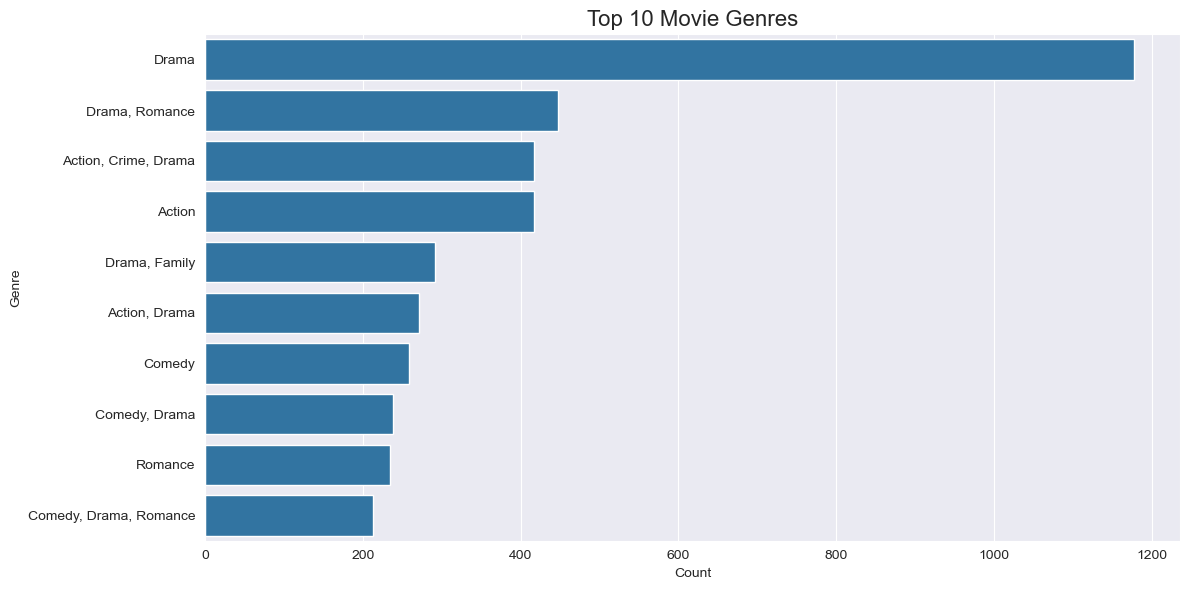

In [10]:
plt.figure(figsize=(12,6))

top_genres = df['Genre'].value_counts().head(10)

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Movie Genres", fontsize=16)
plt.xlabel("Count")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

Rating Distribution

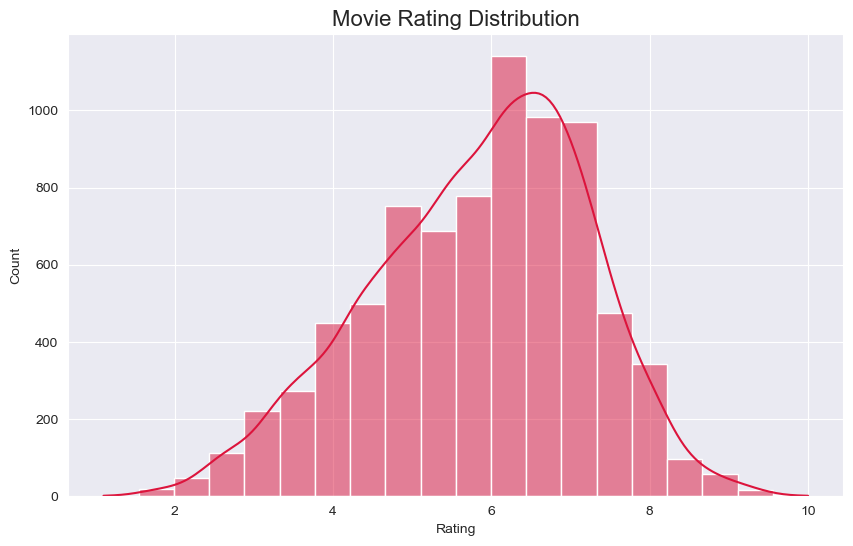

In [11]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Rating'],
    bins=20,
    kde=True,
    color='crimson'
)

plt.title("Movie Rating Distribution", fontsize=16)

plt.show()

Year vs Rating

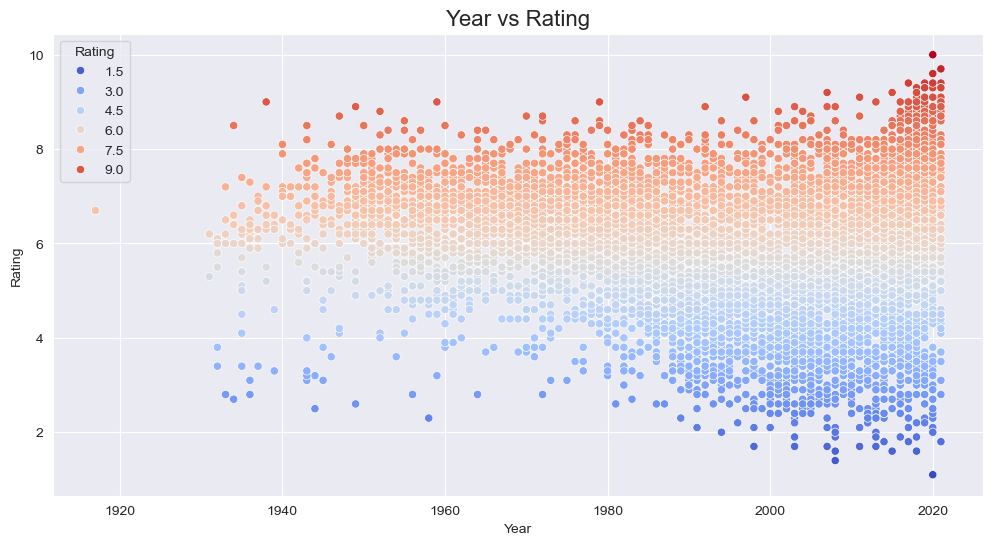

In [12]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    x='Year',
    y='Rating',
    data=df,
    hue='Rating',
    palette='coolwarm'
)

plt.title("Year vs Rating", fontsize=16)

plt.show()

Feature Encoding

In [13]:
le = LabelEncoder()

categorical_cols = [
    'Genre',
    'Director',
    'Actor 1',
    'Actor 2',
    'Actor 3'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),2019,109.0,268,7.0,8,811,1782,2815,377
3,#Yaaram,2019,110.0,207,4.4,35,1749,1589,890,2572
5,...Aur Pyaar Ho Gaya,1997,147.0,177,4.7,827,2005,508,85,2449
6,...Yahaan,2005,142.0,331,7.4,1086,2643,931,1388,3030
8,?: A Question Mark,2012,82.0,367,5.6,326,174,2521,1461,1205


Features and Target

In [14]:
X = df[
    [
        'Year',
        'Duration',
        'Votes',
        'Genre',
        'Director',
        'Actor 1',
        'Actor 2',
        'Actor 3'
    ]
]

y = df['Rating']

print(X.shape)

(7919, 8)


Train Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Model Training

In [16]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


Prediction

In [17]:
y_pred = model.predict(X_test)
print("Prediction Done")

Prediction Done


Model Evaluation

In [18]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae,3))
print("RMSE:", round(rmse,3))
print("R2 Score:", round(r2,3))

MAE : 0.83
RMSE: 1.1
R2 Score: 0.35


Actual vs Predicted Visualization

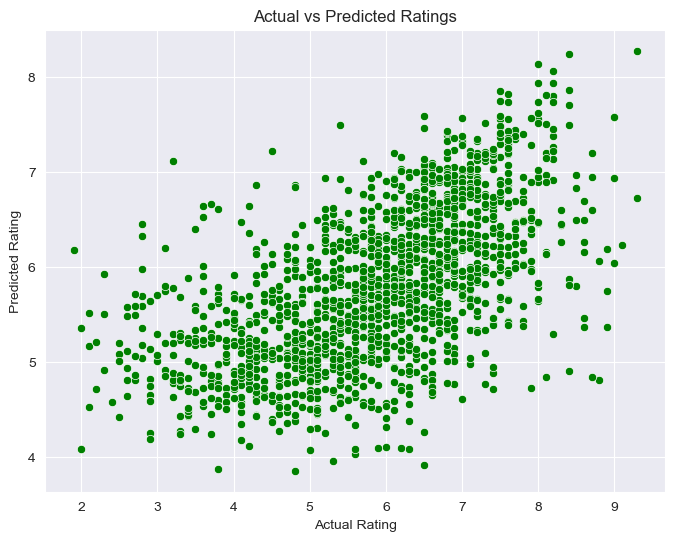

In [19]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=y_pred,
    color='green'
)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings")

plt.show()

Feature Importance

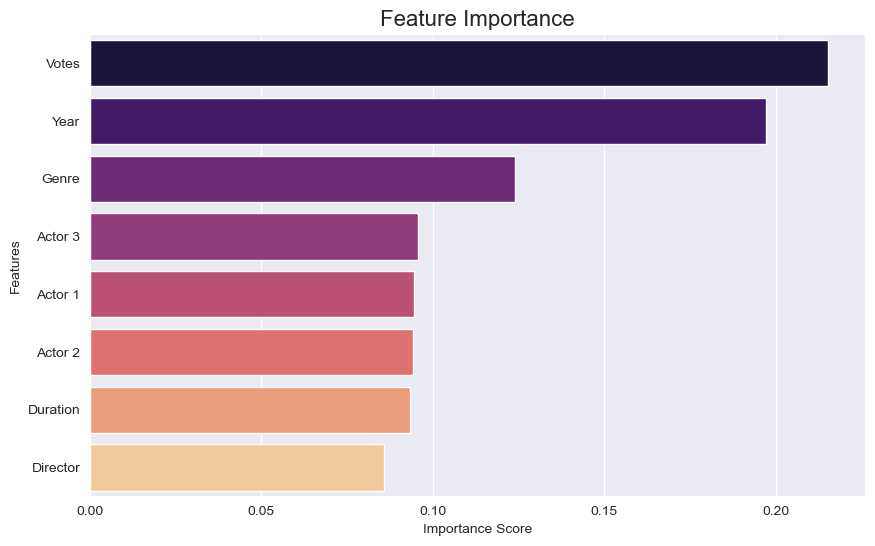

In [20]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='magma',
    legend=False
)

plt.title("Feature Importance", fontsize=16)
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()